### Ejemplo de coaliación del juego de los *Zapatos*

In [1]:
import os
import sys
import math
import pandas as pd
import shap


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_value_of_shoes.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_shoes.csv"
)
original = pd.read_csv(os.path.join(
    "..", "..", "data", "input", "shoes.csv"
), sep=";").set_index(
    "label",
    verify_integrity=True
)

shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only = shapley_only.set_index(
    original.index.values,
    verify_integrity=True
)
psi_1 = original.join(shapley_only)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
).set_index(
    original.index.values,
    verify_integrity=True
)
r_1.columns = original.index.values

### Truncated characteristic values

In [2]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Benefit Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_shoes.csv. In the table below we represent these values:

In [3]:
psi_1_truncated

,player,shoe,value
label,,,
LS 1,Left Shoe 1,L,0.5
LS 2,Left Shoe 2,L,0.5
LS 3,Left Shoe 3,L,0.5
LS 4,Left Shoe 4,L,0.5
LS 5,Left Shoe 5,L,0.5
RS 1,Right Shoe 1,R,0.5
RS 2,Right Shoe 2,R,0.5
RS 3,Right Shoe 3,R,0.5
RS 4,Right Shoe 4,R,0.5


In [4]:
psi_2_truncated

,player,shoe,value
label,,,
LS 1,Left Shoe 1,L,1.0
LS 2,Left Shoe 2,L,1.0
LS 3,Left Shoe 3,L,1.0
LS 4,Left Shoe 4,L,1.0
LS 5,Left Shoe 5,L,1.0
RS 1,Right Shoe 1,R,1.0
RS 2,Right Shoe 2,R,1.0
RS 3,Right Shoe 3,R,1.0
RS 4,Right Shoe 4,R,1.0


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_shoes.csv. In the following table, we represent these values.

In [5]:
r_1_truncated

,LS 1,LS 2,LS 3,LS 4,LS 5,RS 1,RS 2,RS 3,RS 4,RS 5
LS 1,0.0000,-0.2580,-0.2580,-0.2580,-0.2580,0.4063,0.4063,0.4063,0.4063,0.4063
LS 2,-0.2580,0.0000,-0.2580,-0.2580,-0.2580,0.4063,0.4063,0.4063,0.4063,0.4063
LS 3,-0.2580,-0.2580,0.0000,-0.2580,-0.2580,0.4063,0.4063,0.4063,0.4063,0.4063
LS 4,-0.2580,-0.2580,-0.2580,0.0000,-0.2580,0.4063,0.4063,0.4063,0.4063,0.4063
LS 5,-0.2580,-0.2580,-0.2580,-0.2580,0.0000,0.4063,0.4063,0.4063,0.4063,0.4063
RS 1,0.4063,0.4063,0.4063,0.4063,0.4063,0.0000,-0.2580,-0.2580,-0.2580,-0.2580
RS 2,0.4063,0.4063,0.4063,0.4063,0.4063,-0.2580,0.0000,-0.2580,-0.2580,-0.2580
RS 3,0.4063,0.4063,0.4063,0.4063,0.4063,-0.2580,-0.2580,0.0000,-0.2580,-0.2580
RS 4,0.4063,0.4063,0.4063,0.4063,0.4063,-0.2580,-0.2580,-0.2580,0.0000,-0.2580
RS 5,0.4063,0.4063,0.4063,0.4063,0.4063,-0.2580,-0.2580,-0.2580,-0.2580,0.0000


In [6]:
r_2_truncated

,LS 1,LS 2,LS 3,LS 4,LS 5,RS 1,RS 2,RS 3,RS 4,RS 5
LS 1,0.0000,-0.6348,-0.6348,-0.6348,-0.6348,1.0000,1.0000,1.0000,1.0000,1.0000
LS 2,-0.6348,0.0000,-0.6348,-0.6348,-0.6348,1.0000,1.0000,1.0000,1.0000,1.0000
LS 3,-0.6348,-0.6348,0.0000,-0.6348,-0.6348,1.0000,1.0000,1.0000,1.0000,1.0000
LS 4,-0.6348,-0.6348,-0.6348,0.0000,-0.6348,1.0000,1.0000,1.0000,1.0000,1.0000
LS 5,-0.6348,-0.6348,-0.6348,-0.6348,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
RS 1,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,-0.6348,-0.6348,-0.6348,-0.6348
RS 2,1.0000,1.0000,1.0000,1.0000,1.0000,-0.6348,0.0000,-0.6348,-0.6348,-0.6348
RS 3,1.0000,1.0000,1.0000,1.0000,1.0000,-0.6348,-0.6348,0.0000,-0.6348,-0.6348
RS 4,1.0000,1.0000,1.0000,1.0000,1.0000,-0.6348,-0.6348,-0.6348,0.0000,-0.6348
RS 5,1.0000,1.0000,1.0000,1.0000,1.0000,-0.6348,-0.6348,-0.6348,-0.6348,0.0000


### Absolute value $\|I\|$

In [7]:
r_1_abs = r_1.astype(float).apply(lambda row: row.apply(lambda number: abs(number)))
r_1_abs

,LS 1,LS 2,LS 3,LS 4,LS 5,RS 1,RS 2,RS 3,RS 4,RS 5
LS 1,0.000000,0.257937,0.257937,0.257937,0.257937,0.406349,0.406349,0.406349,0.406349,0.406349
LS 2,0.257937,0.000000,0.257937,0.257937,0.257937,0.406349,0.406349,0.406349,0.406349,0.406349
LS 3,0.257937,0.257937,0.000000,0.257937,0.257937,0.406349,0.406349,0.406349,0.406349,0.406349
LS 4,0.257937,0.257937,0.257937,0.000000,0.257937,0.406349,0.406349,0.406349,0.406349,0.406349
LS 5,0.257937,0.257937,0.257937,0.257937,0.000000,0.406349,0.406349,0.406349,0.406349,0.406349
RS 1,0.406349,0.406349,0.406349,0.406349,0.406349,0.000000,0.257937,0.257937,0.257937,0.257937
RS 2,0.406349,0.406349,0.406349,0.406349,0.406349,0.257937,0.000000,0.257937,0.257937,0.257937
RS 3,0.406349,0.406349,0.406349,0.406349,0.406349,0.257937,0.257937,0.000000,0.257937,0.257937
RS 4,0.406349,0.406349,0.406349,0.406349,0.406349,0.257937,0.257937,0.257937,0.000000,0.257937
RS 5,0.406349,0.406349,0.406349,0.406349,0.406349,0.257937,0.257937,0.257937,0.257937,0.000000


In [8]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 1}^{2}; R_{\beta^{+} = 1; \beta^{-} = 0}^{2}$

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


Saving the graph to ../../results/Cap3/Fig5.jpg


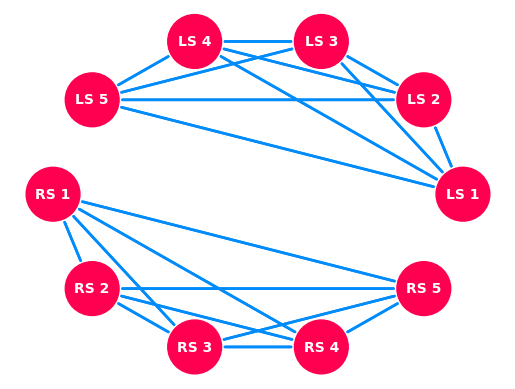

In [9]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=1,
    positive_beta=1,
    negative_beta=0,
    symmetric=True,
    layout="circular",
    positive_color=positive_color,
    negative_color=negative_color,
    output_path=os.path.join('..', '..', 'results', 'Cap3', 'Fig5.jpg')
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 1}^{2}; R_{\beta^{+} = 0; \beta^{-} = 1}^{2}$

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


Saving the graph to ../../results/Cap3/Fig6.jpg


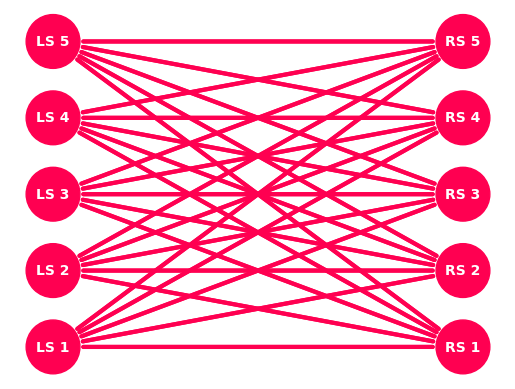

In [10]:
import os
import sys
sys.path.append(os.path.join("..", "..", "."))

from cgt_perezsechi.visualization.graph import draw


node_pos = {
    "LS 5": [1, 5],
    "LS 4": [1, 4],
    "LS 3": [1, 3],
    "LS 2": [1, 2],
    "LS 1": [1, 1],
    "RS 5": [5, 5],
    "RS 4": [5, 4],
    "RS 3": [5, 3],
    "RS 2": [5, 2],
    "RS 1": [5, 1],
}

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=1,
    positive_beta=0,
    negative_beta=1,
    symmetric=True,
    # layout="circular",
    node_pos=node_pos,
    positive_color=positive_color,
    negative_color=negative_color,
    output_path=os.path.join('..', '..', 'results', 'Cap3', 'Fig6.jpg')
)